Nome: Sofia Ballerini de Vasconcellos

RA: 299904

Curso: Doutorado Eng. Elétrica



# Ex04 - Filtragem de Imagens

Nesta atividade vamos entender a operação de convolução e o uso da mesma para filtragem de imagens. Testaremos o uso de **filtros suavizantes**, usados para a remoção de ruído, e **filtros aguçantes**, usados para detecção de bordas.  

- **Filtros suavizantes:** são aqueles que removem a nitidez da imagem fazendo uma média, aritmética ou ponderada, na janela do núcleo. O filtro ponderado suavizante mais comum é o da gaussiana. Filtros suavizantes são muito utilizados para eliminar ruído de uma imagem.

- **Filtros aguçantes:** são aqueles que realçam as bordas da imagem. Alguns dos filtros aguçantes comuns são: Filtro de Sobel, Filtro de Prewitt, Filtro Laplaciano.

Veja mais no notebook sobre [Filtragem no domínio espacial](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/07_Filtragem_no_dominio_espacial.ipynb)

In [21]:
# Importando as bibliotecas que serão utilizadas
import os
import random
import shutil

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

Download das imagens:

In [22]:
zip_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/FiltragemDeImagens.zip"

if not os.path.exists("FiltragemDeImagens.zip"):
    response = requests.get(zip_url)
    with open("FiltragemDeImagens.zip", mode="wb") as file:
        file.write(response.content)

if not os.path.exists("FiltragemDeImagens"):
    shutil.unpack_archive("FiltragemDeImagens.zip")

In [23]:
path = "FiltragemDeImagens/"

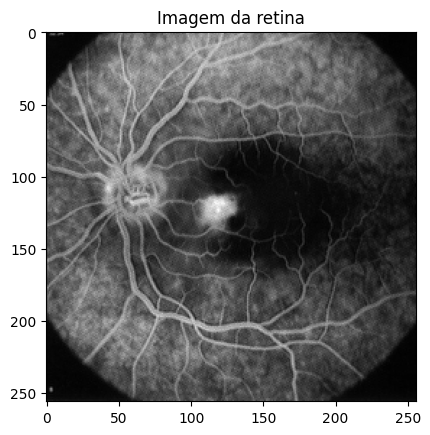

In [24]:
%matplotlib inline
f = mpimg.imread(path+'retina.tif')
plt.title('Imagem da retina')
plt.imshow(f,cmap='gray')

**ATENÇÃO** - as operações de filtragem alteram os valores e eles podem sair da faixa de 0 a 255. Portanto, fique atento à maneira como você está realizando as operações e visualizando os resultados. Algumas dicas:

- Uma boa prática é realizar as operações em ponto flutuante;
- Quando a visualização não corresponde ao esperado, desconfie que os valores sairam da escala e que os valores, de alguma maneira, estão sendo truncados.

## Parte 1 - Operação de convolução e filtro da média

### Exercício 1.1

Entenda o uso da operação de convolução e experimente usá-la para entender o filtro da média. Siga o seguinte roteiro:
- Crie uma imagem numérica pequena (7x7, por exemplo), crie um filtro de média (kernel 3x3) e use a função **convolve()** da biblioteca **scipy.ndimage** para realizar a filtragem. Verifique numericamente que a filtragem está correta;
- Repita a operação de filtragem na imagem da retina e visualize o resultado;
- Faça experimentos com a imagem da retina variando o tamanho do filtro e compare as imagens resultantes;
- Não se esqueça de comentar os métodos utilizados e resultados obtidos.

kernel=
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


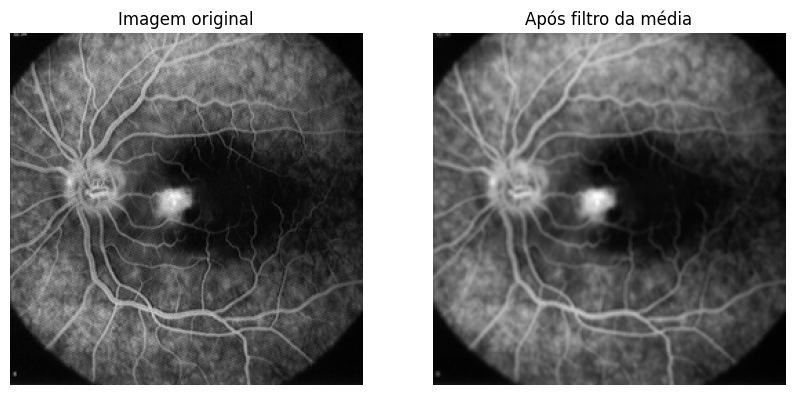

In [47]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from scipy.ndimage import convolve

f = mpimg.imread(path+'retina.tif')

# Define o tamanho do kernel (janela do filtro)
s = 3

# Cria um kernel de média 3x3 (todos valores iguais, soma = 1)
# Esse kernel realiza suavização ao calcular a média dos pixels vizinhos
k = np.ones((s,s))/(s*s)

# Aplica a operação de convolução entre a imagem e o kernel
# Cada pixel da imagem será substituído pela média da sua vizinhança
f_conv_fmean = convolve(f,k)

print('kernel=\n',k)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagem original')
plt.imshow(f, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title('Após filtro da média')
plt.imshow(f_conv_fmean, cmap='gray')
plt.axis('off');



A imagem da retina foi carregada com imread, sendo convertida em uma matriz NumPy para processamento. Em seguida, foi criado um kernel de média 3x3 com np.ones, normalizado para que a soma dos valores seja igual a 1.
A filtragem foi realizada com a função convolve, que aplica a operação de convolução substituindo cada pixel pela média dos valores da sua vizinhança.

In [44]:
#VERIFICAÇÃO

img = np.array([
    [10,10,10,10,10,10,10],
    [10,50,50,50,50,50,10],
    [10,50,100,100,100,50,10],
    [10,50,100,200,100,50,10],
    [10,50,100,100,100,50,10],
    [10,50,50,50,50,50,10],
    [10,10,10,10,10,10,10]
], dtype=float)

k = np.ones((3,3))/9

resultado = convolve(img, k)
print(resultado)


[[ 14.44444444  18.88888889  23.33333333  23.33333333  23.33333333
   18.88888889  14.44444444]
 [ 18.88888889  33.33333333  47.77777778  53.33333333  47.77777778
   33.33333333  18.88888889]
 [ 23.33333333  47.77777778  83.33333333  94.44444444  83.33333333
   47.77777778  23.33333333]
 [ 23.33333333  53.33333333  94.44444444 111.11111111  94.44444444
   53.33333333  23.33333333]
 [ 23.33333333  47.77777778  83.33333333  94.44444444  83.33333333
   47.77777778  23.33333333]
 [ 18.88888889  33.33333333  47.77777778  53.33333333  47.77777778
   33.33333333  18.88888889]
 [ 14.44444444  18.88888889  23.33333333  23.33333333  23.33333333
   18.88888889  14.44444444]]


A verificação foi realizada aplicando a convolução em uma matriz 7x7 com valores conhecidos. Em seguida, comparou-se o valor de um pixel interno, calculando a média dos elementos da vizinhança 3x3. O valor obtido coincidiu com o valor retornado pela função convolve, confirmando que a filtragem foi aplicada corretamente.

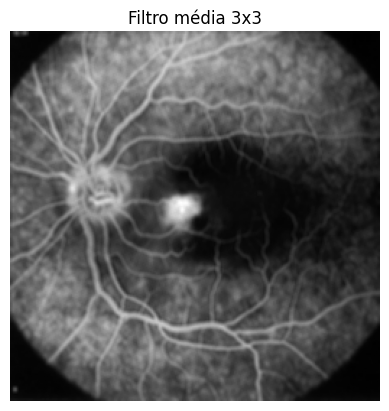

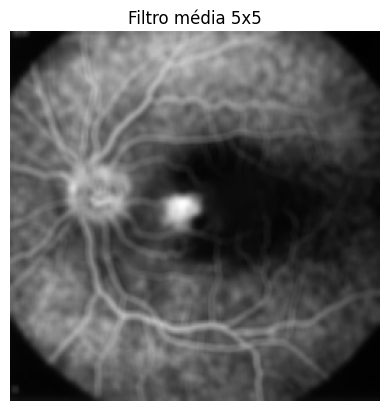

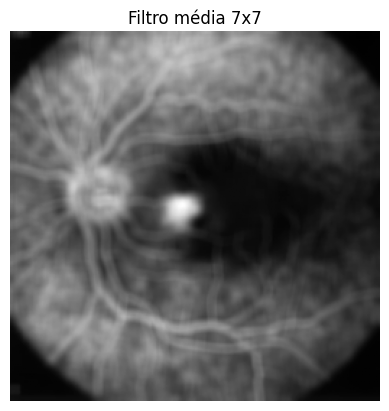

In [46]:
# Variando o tamanho do kernel (3,5 e 7)

for s in [3,5,7]:
    k = np.ones((s,s))/(s*s)
    img_filtrada = convolve(f, k)

    plt.figure()
    plt.title(f'Filtro média {s}x{s}')
    plt.imshow(img_filtrada, cmap='gray')
    plt.axis('off')

Filtro 3x3: produz uma suavização leve. A imagem ainda mantém boa parte dos detalhes.
Filtro 5x5: aumenta a suavização. Pequenos detalhes e bordas começam a ficar menos nítidos.
Filtro 9x9: gera uma suavização forte. A imagem fica mais borrada e perde bastante detalhe.

### Exercício 1.2

Repita a operação de filtragem, desta vez variando também o modo de tratamento de borda da função **convolve()** - '*reflect*', '*constant*', '*nearest*', '*mirror*', '*wrap*' - explicando as diferenças encontradas. Dica, você só conseguirá visualizar as diferenças se aumentar o tamanho da máscara (filtro).

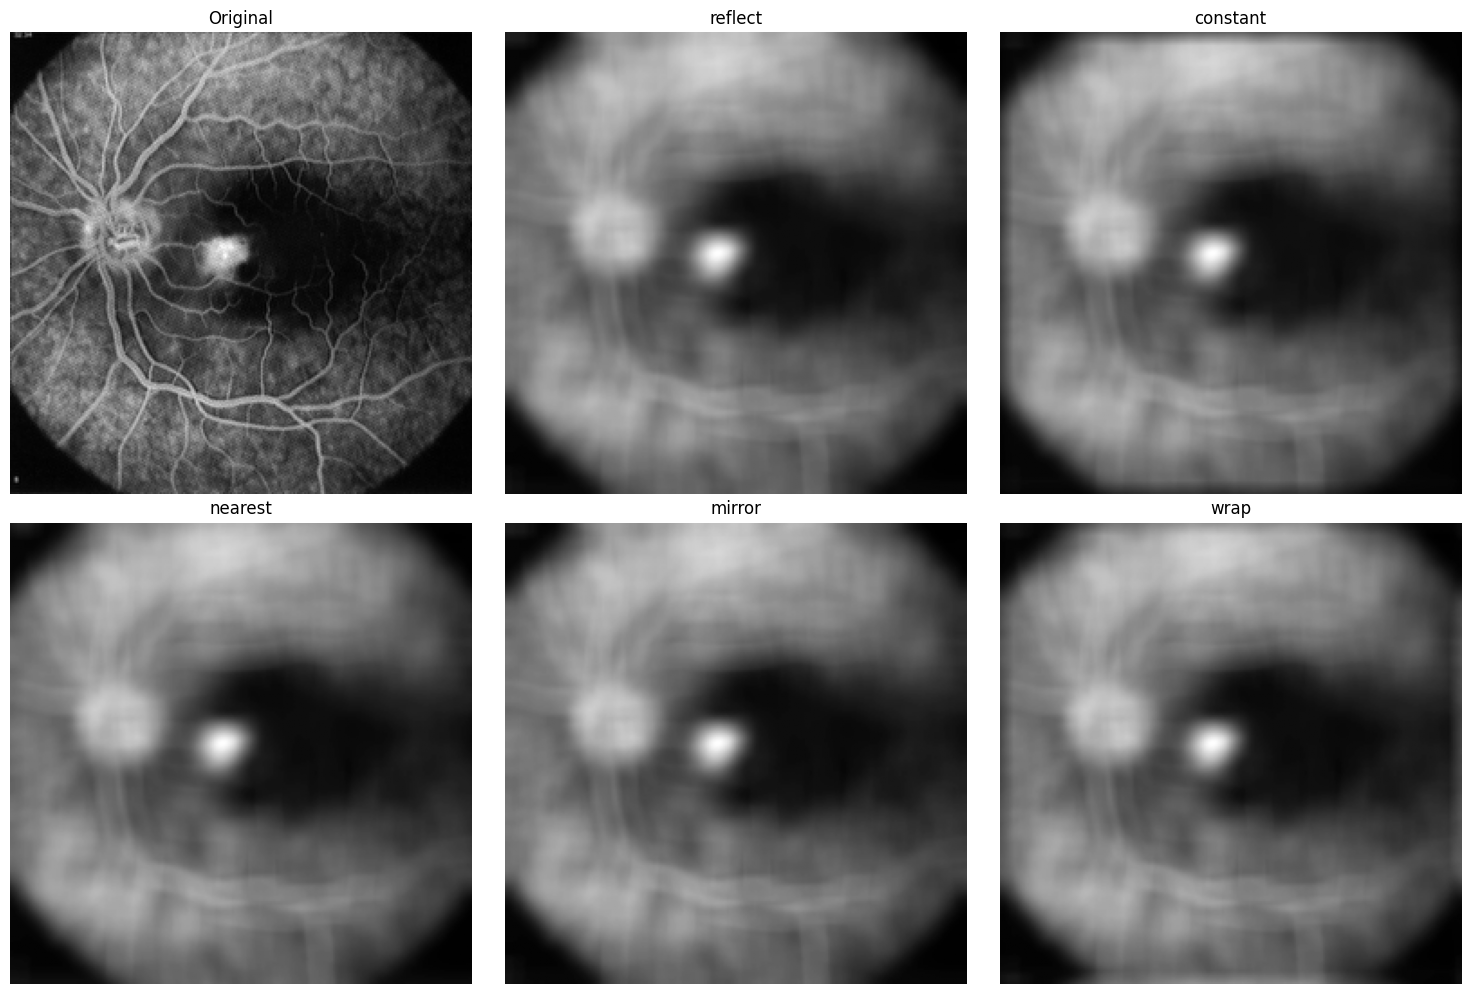

In [53]:
# carregar imagem
f = mpimg.imread(path + 'retina.tif')

# verificar se a imagem é colorida
if len(f.shape) == 3:
    f_gray = rgb2gray(f)
else:
    f_gray = f

# Define o tamanho do kernel (janela do filtro)
s = 15

# máscara maior para destacar diferenças nas bordas
k = np.ones((s,s)) / (s*s)

# modos de borda
modos = ['reflect', 'constant', 'nearest', 'mirror', 'wrap']

# aplicar convolução
resultados = {}
for modo in modos:
    if modo == 'constant':
        resultados[modo] = convolve(f_gray, k, mode=modo, cval=0.0)
    else:
        resultados[modo] = convolve(f_gray, k, mode=modo)

# mostrar resultados
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(f_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, modo in enumerate(modos, start=2):
    plt.subplot(2,3,i)
    plt.imshow(resultados[modo], cmap='gray')
    plt.title(modo)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [54]:
for modo in ['constant', 'nearest', 'mirror', 'wrap']:
    diferenca = np.abs(resultados[modo] - resultados['reflect'])
    print(modo, diferenca.max(), diferenca.mean())

constant 255 24.992630004882812
nearest 255 12.656356811523438
mirror 255 3.402618408203125
wrap 255 12.700698852539062


Embora as imagens filtradas pareçam visualmente muito semelhantes quando observadas por inteiro, a comparação numérica mostrou que os resultados não são iguais. Ao calcular a diferença absoluta entre cada modo e o modo reflect, observou-se que todos apresentaram diferenças diferentes de zero. O modo mirror foi o mais próximo de reflect, enquanto constant foi o mais diferente. Isso confirma que o tratamento de borda influencia o resultado da convolução, mesmo que essa diferença nem sempre seja facilmente perceptível na visualização global da imagem.

## Parte 2 - Filtro gaussiano e redução de ruído

### Exercício 2.1

Teste a propriedade de decomposição das máscaras da convolução, ou seja, crie um filtro gaussiano bi-dimensional (3,3) a partir de 2 filtros unidimensionais (3,1) e (1,3). Crie também o filtro bi-dimensional diretamente e cheque se os resultados são equivalentes. Comente os métodos utilizados.

In [55]:
# imagem de teste
img = np.array([
    [10,10,10,10,10,10,10],
    [10,50,50,50,50,50,10],
    [10,50,100,100,100,50,10],
    [10,50,100,200,100,50,10],
    [10,50,100,100,100,50,10],
    [10,50,50,50,50,50,10],
    [10,10,10,10,10,10,10]
], dtype=float)

# filtros gaussianos 1D
g_vertical = np.array([[1],
                       [2],
                       [1]], dtype=float) / 4

g_horizontal = np.array([[1, 2, 1]], dtype=float) / 4

# filtro gaussiano 2D por decomposição
g_2d_decomp = g_vertical @ g_horizontal

# filtro gaussiano 2D criado diretamente
g_2d_direto = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=float) / 16

# aplicação por duas convoluções 1D
resultado_1d = convolve(img, g_vertical, mode='constant', cval=0.0)
resultado_1d = convolve(resultado_1d, g_horizontal, mode='constant', cval=0.0)

# aplicação direta do filtro 2D
resultado_2d = convolve(img, g_2d_direto, mode='constant', cval=0.0)

print("Filtro gaussiano 2D por decomposição:\n", g_2d_decomp)
print("\nFiltro gaussiano 2D direto:\n", g_2d_direto)

print("\nOs filtros são iguais? ", np.allclose(g_2d_decomp, g_2d_direto))
print("Os resultados filtrados são equivalentes? ", np.allclose(resultado_1d, resultado_2d))

print("\nResultado com filtros 1D:\n", resultado_1d)
print("\nResultado com filtro 2D direto:\n", resultado_2d)

Filtro gaussiano 2D por decomposição:
 [[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]

Filtro gaussiano 2D direto:
 [[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]

Os filtros são iguais?  True
Os resultados filtrados são equivalentes?  True

Resultado com filtros 1D:
 [[  8.125  15.     17.5    17.5    17.5    15.      8.125]
 [ 15.     35.625  49.375  52.5    49.375  35.625  15.   ]
 [ 17.5    49.375  84.375 100.     84.375  49.375  17.5  ]
 [ 17.5    52.5   100.    125.    100.     52.5    17.5  ]
 [ 17.5    49.375  84.375 100.     84.375  49.375  17.5  ]
 [ 15.     35.625  49.375  52.5    49.375  35.625  15.   ]
 [  8.125  15.     17.5    17.5    17.5    15.      8.125]]

Resultado com filtro 2D direto:
 [[  8.125  15.     17.5    17.5    17.5    15.      8.125]
 [ 15.     35.625  49.375  52.5    49.375  35.625  15.   ]
 [ 17.5    49.375  84.375 100.     84.375  49.375  17.5  ]
 [ 17.5    52.5   100.    125.    100.     52.5    17.

Foi usado o conceito de separabilidade do filtro gaussiano, que permite escrever um filtro 2D como produto de dois filtros 1D. Isso é importante porque reduz o custo computacional: em vez de aplicar uma convolução bidimensional diretamente, pode-se aplicar duas convoluções unidimensionais em sequência.
A função convolve() foi utilizada para realizar as filtragens, mantendo o mesmo modo de tratamento de borda em todos os casos para garantir uma comparação correta. A comparação foi feita com np.allclose(), que verifica se duas matrizes possuem valores iguais dentro de uma pequena tolerância numérica.

A comparação mostrou que os dois filtros são iguais. Depois, a filtragem da imagem foi feita de duas formas: aplicando dois filtros 1D em sequência e aplicando diretamente o filtro 2D. Os resultados obtidos também foram equivalentes, como indicado pelo retorno True.


### Exercício 2.2

Teste a aplicação de filtros suavizantes para redução de ruído: Adicione ruído gaussiano à imagem da retina (sugestão: use **np.random**) e depois tente remover o ruído com o filtro da média e com o filtro gaussiano. Você pode aumentar os filtros se quiser. Comente os métodos utilizados e resultados obtidos.

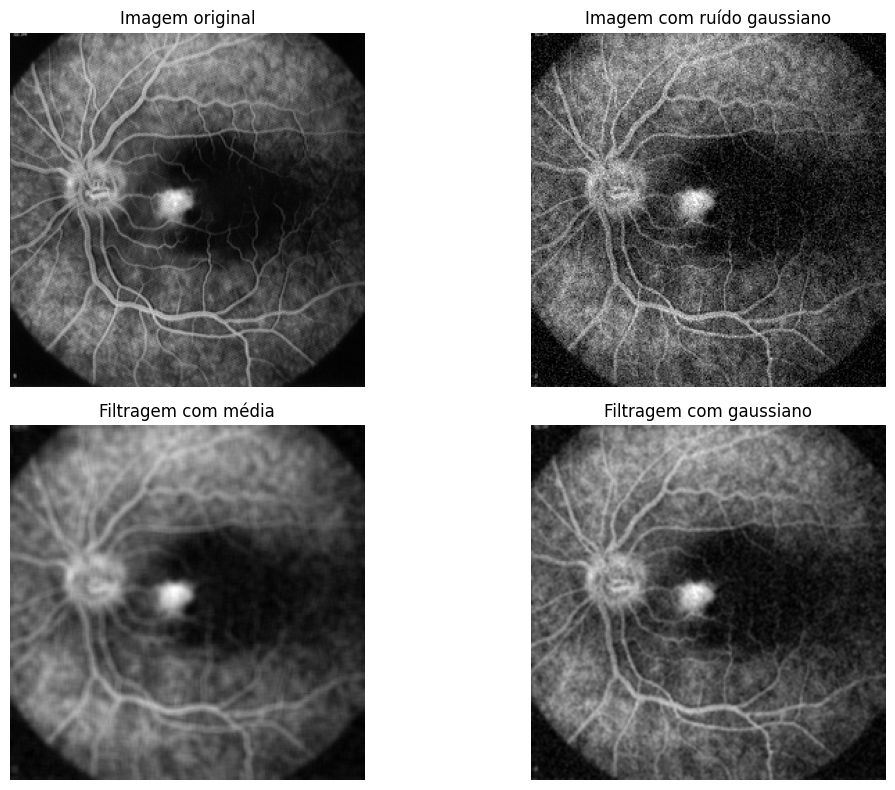

In [57]:
# carregar imagem
f = mpimg.imread(path + 'retina.tif')

# garantir imagem em float
f = f.astype(float)

# se a imagem tiver 3 canais, usar apenas um canal ou converter
if len(f.shape) == 3:
    f = f[..., 0]

# normalizar se necessário
if f.max() > 1:
    f = f / 255.0


# 1. Adicionar ruído gaussiano
np.random.seed(0)
ruido = np.random.normal(loc=0, scale=0.08, size=f.shape)

f_ruidosa = f + ruido
f_ruidosa = np.clip(f_ruidosa, 0, 1)


# 2. Filtro da média
k_media = np.ones((5,5)) / 25
f_media = convolve(f_ruidosa, k_media, mode='reflect')


# 3. Filtro gaussiano
k_gauss = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=float) / 16

f_gauss = convolve(f_ruidosa, k_gauss, mode='reflect')


# 4. Visualização
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(f, cmap='gray')
plt.title('Imagem original')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(f_ruidosa, cmap='gray')
plt.title('Imagem com ruído gaussiano')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(f_media, cmap='gray')
plt.title('Filtragem com média')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(f_gauss, cmap='gray')
plt.title('Filtragem com gaussiano')
plt.axis('off')

plt.tight_layout()
plt.show()

Neste exercício foi adicionado ruído gaussiano à imagem da retina usando valores aleatórios gerados com np.random.normal(). Em seguida, foram aplicados dois filtros suavizantes, o filtro da média e o filtro gaussiano.
O filtro da média conseguiu reduzir o ruído, porém causou forte borramento da imagem, com perda visível de detalhes e contornos. Já o filtro gaussiano também reduziu o ruído, mas preservou melhor as estruturas da retina, produzindo um resultado visualmente mais equilibrado. Isso acontece porque o filtro da média atribui o mesmo peso a todos os pixels da vizinhança, enquanto o filtro gaussiano dá maior peso aos pixels centrais. Assim, o filtro gaussiano se mostrou mais eficiente para suavizar o ruído sem degradar tanto a imagem.

## Parte 3 - Filtro de Sobel e detecção de bordas

Existem vários filtros que procuram realçar as bordas da imagem. Um dos mais conhecidos é o Operador Sobel, composto por uma máscara vertical (Sv) e uma máscara horizontal (Sh).

In [29]:
Sv = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
print('Sv =\n',Sv)

Sh = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
print('Sh =\n',Sh)

Sv =
 [[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]
Sh =
 [[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


Para detectar bordas de uma imagem usando o Filtro de Sobel, precisamos fazer a filtragem da imagem usando tanto a máscara vertical, quanto a horizontal. No final, acabaremos com 2 imagens resultantes, uma reforçando as bordas verticais e outra reforçando as bordas horizontais, como exemplificado abaixo.

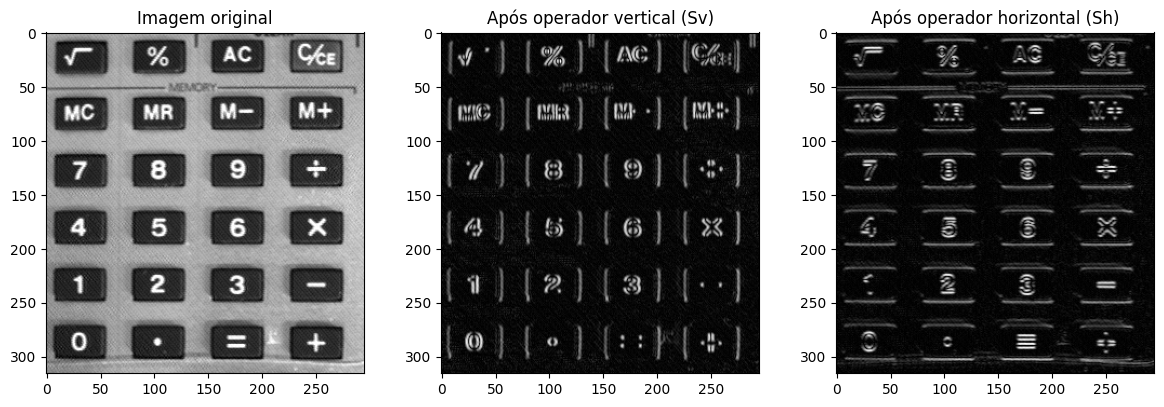

In [30]:
img = mpimg.imread(path+'keyb.tif')
img_sv = mpimg.imread(path+'keyb_sv.tif')
img_sh = mpimg.imread(path+'keyb_sh.tif')

fig, axs = plt.subplots(1,3, figsize=(12, 4))
plt.tight_layout()

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Imagem original')

plt.subplot(132)
plt.imshow(img_sv,cmap='gray')
plt.title('Após operador vertical (Sv)')

plt.subplot(133)
plt.imshow(img_sh,cmap='gray')
plt.title('Após operador horizontal (Sh)');

### Exercício 3.1 - Visualizando as bordas verticais e horizontais em 2 imagens separadas

Experimente filtrar as imagens abaixo com os Filtros de Sobel vertical e horizontal e visualize o resultado. Para cada imagem, você deve obter uma imagem fitrada pelo Filtro de Sobel vertical - **fv** - e uma imagem filtrada pelo Filtro de Sobel horizontal - **fh**. Comente sobre os resultados obtidos. As imagens geradas estão de acordo com o exemplo apresentado para a imagem da calculadora? Em caso negativo, explique o porquê e tente fazer com que as imagens fiquem mais semelhantes.

In [31]:
img1 = mpimg.imread(path+'retina.tif')

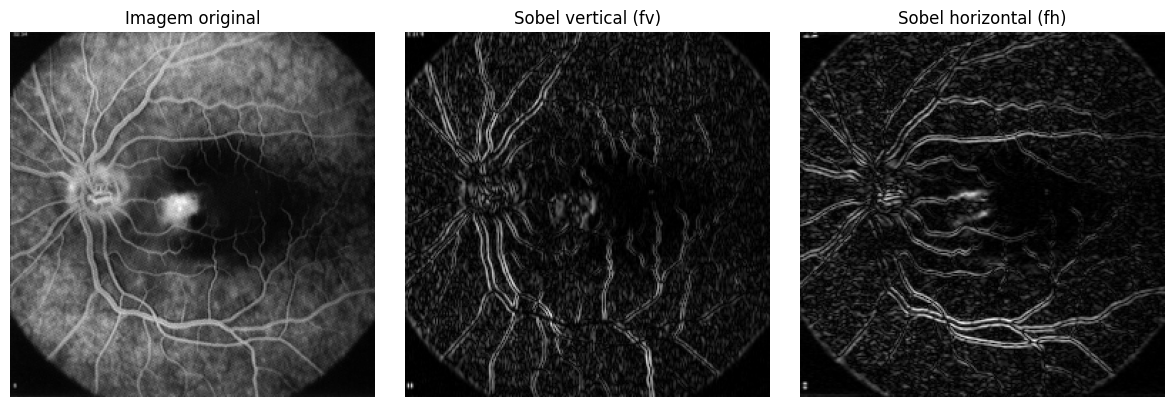

In [58]:
# Se a imagem tiver mais de um canal, usa apenas um
if len(img1.shape) == 3:
    img1 = img1[..., 0]

img1 = img1.astype(float)

Sv = np.array([[1, 0, -1],
               [2, 0, -2],
               [1, 0, -1]])

Sh = np.array([[ 1,  2,  1],
               [ 0,  0,  0],
               [-1, -2, -1]])

# Aplicação dos filtros
fv = convolve(img1, Sv, mode='reflect')
fh = convolve(img1, Sh, mode='reflect')

# Valor absoluto
fv_abs = np.abs(fv)
fh_abs = np.abs(fh)

# Normalização para [0,1]
fv_abs = fv_abs / fv_abs.max()
fh_abs = fh_abs / fh_abs.max()

# Exibição
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img1, cmap='gray')
plt.title('Imagem original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(fv_abs, cmap='gray')
plt.title('Sobel vertical (fv)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(fh_abs, cmap='gray')
plt.title('Sobel horizontal (fh)')
plt.axis('off')

plt.tight_layout()
plt.show()

---

In [33]:
img2 = mpimg.imread(path+'cameraman.tif')

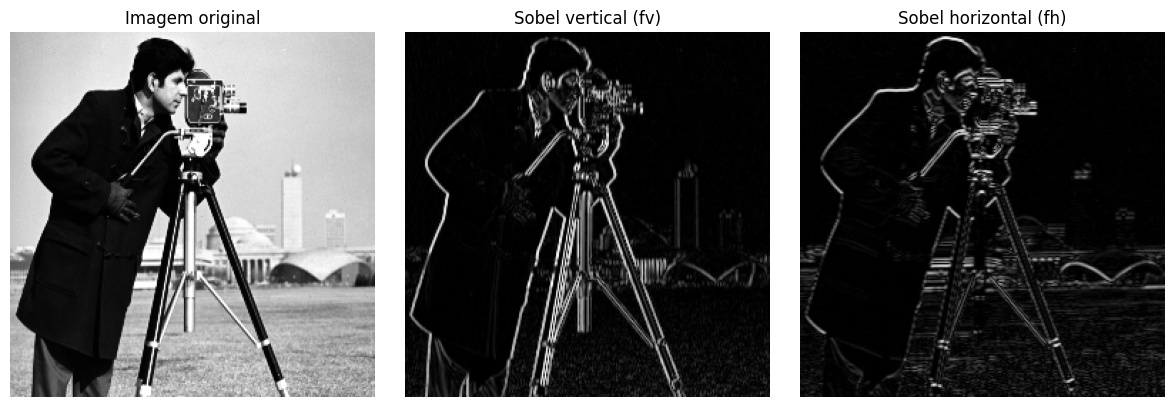

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.ndimage import convolve

img2 = mpimg.imread(path + 'cameraman.tif')

# Se a imagem tiver mais de um canal, usa apenas um
if len(img2.shape) == 3:
    img2 = img2[..., 0]

img2 = img2.astype(float)

Sv = np.array([[1, 0, -1],
               [2, 0, -2],
               [1, 0, -1]])

Sh = np.array([[ 1,  2,  1],
               [ 0,  0,  0],
               [-1, -2, -1]])

# Aplicação dos filtros
fv2 = convolve(img2, Sv, mode='reflect')
fh2 = convolve(img2, Sh, mode='reflect')

# Valor absoluto
fv2_abs = np.abs(fv2)
fh2_abs = np.abs(fh2)

# Normalização
fv2_abs = fv2_abs / fv2_abs.max()
fh2_abs = fh2_abs / fh2_abs.max()

# Exibição
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img2, cmap='gray')
plt.title('Imagem original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(fv2_abs, cmap='gray')
plt.title('Sobel vertical (fv)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(fh2_abs, cmap='gray')
plt.title('Sobel horizontal (fh)')
plt.axis('off')

plt.tight_layout()
plt.show()

Os resultados ficaram coerentes com o exemplo da calculadora, mas com diferenças visuais esperadas por causa do conteúdo de cada imagem.

Na calculadora, o efeito do Sobel aparece de forma mais “limpa” e organizada, porque a imagem tem bordas retas, alto contraste e objetos bem definidos. Por isso, o operador vertical destaca principalmente as laterais dos botões e números, enquanto o horizontal destaca as bordas de cima e de baixo. Já retina, o comportamento é um pouco diferente. As estruturas da retina são mais orgânicas, curvas, finas e com contraste menos uniforme. Por isso, as respostas do Sobel ficam mais espalhadas e com aspecto mais texturizado. Mesmo assim, o filtro vertical realçou melhor bordas associadas a estruturas verticais dos vasos, e o horizontal destacou melhor as estruturas horizontais. Enquanto na imagem do cameraman, o resultado ficou mais próximo do exemplo da calculadora. Isso acontece porque a cena possui contornos mais fortes e formas mais definidas, como o tripé, o corpo do fotógrafo e estruturas do fundo. Assim, fica mais fácil perceber a separação entre bordas verticais e horizontais.

### Exercício 3.2 - Visualizando todas as bordas em uma única imagem

Para visualizar o resultado das 2 filtragens (horizontal e vertical) em uma única imagem, utilizamos a magnitude de Sobel. A função MagSobel (a ser implementada) possui como parâmetro a imagem de entrada e deve seguir a seguinte equação:

$$MagSobel = \sqrt{f_h^2 + f_v^2}$$

onde $f_h$ é a imagem de entrada convolvida com o operador de Sobel horizontal e $f_v$ é a imagem de entrada convolvida com o operador de Sobel vertical. Crie esta função e visualize a Magnitude de Sobel das imagens utilizadas no exercício 3.1.

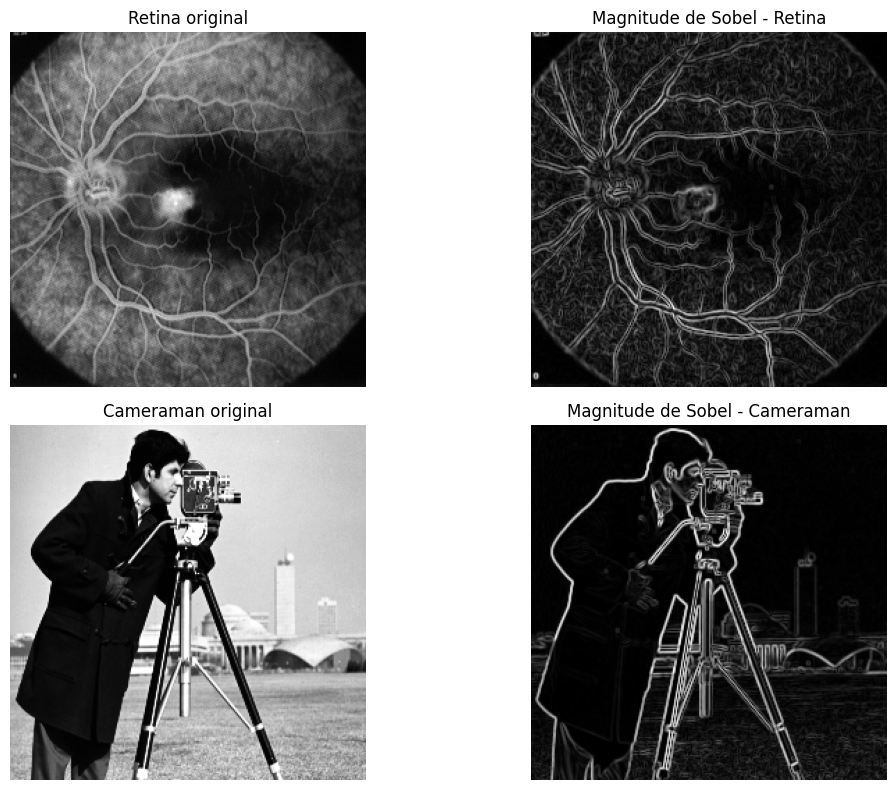

In [60]:
# Máscaras de Sobel
Sv = np.array([[1, 0, -1],
               [2, 0, -2],
               [1, 0, -1]])

Sh = np.array([[ 1,  2,  1],
               [ 0,  0,  0],
               [-1, -2, -1]])

def MagSobel(img):
    img = img.astype(float)

    # Se a imagem tiver mais de um canal, usa apenas um
    if len(img.shape) == 3:
        img = img[..., 0]

    fv = convolve(img, Sv, mode='reflect')
    fh = convolve(img, Sh, mode='reflect')

    mag = np.sqrt(fv**2 + fh**2)

    # normalização para melhorar a visualização
    mag = mag / mag.max()

    return mag

# carregar imagens
img1 = mpimg.imread(path + 'retina.tif')
img2 = mpimg.imread(path + 'cameraman.tif')

# aplicar magnitude de Sobel
mag1 = MagSobel(img1)
mag2 = MagSobel(img2)

# exibir resultados
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img1, cmap='gray')
plt.title('Retina original')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(mag1, cmap='gray')
plt.title('Magnitude de Sobel - Retina')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img2, cmap='gray')
plt.title('Cameraman original')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(mag2, cmap='gray')
plt.title('Magnitude de Sobel - Cameraman')
plt.axis('off')

plt.tight_layout()
plt.show()

A função MagSobel foi implementada calculando a convolução da imagem com os operadores de Sobel vertical e horizontal, obtendo as imagens fv e fh. Em seguida, foi calculada a magnitude de Sobel usando a expressão MagSobel = raiz quadrada de (fv² + fh²), reunindo em uma única imagem as bordas detectadas nas duas direções.

Os resultados mostraram que a magnitude de Sobel destaca bem as bordas gerais da imagem. Na retina, foram evidenciados os vasos sanguíneos e outras estruturas finas e curvas, produzindo uma imagem com mais detalhes e textura. Já na imagem cameraman, a magnitude destacou de forma mais clara os contornos do fotógrafo, da câmera e do tripé. Dessa forma, a magnitude de Sobel se mostrou eficiente para visualizar todas as bordas em uma única imagem, combinando as contribuições dos filtros vertical e horizontal.

## Parte 4 - Aprendendo filtros com CNN (opcional para EA979)

Como vimos em sala de aula, as redes neurais convolucionais (CNNs, do inglês *convolutional neural networks*) têm como base as camadas convolucionais, um banco de filtros cujos pesos são aprendidos a partir de um gabarito para predição. Para entender melhor como isso funciona, vamos praticar com redes convolucionais bem simples e visualizar como os filtros são aprendidos por elas.

Vamos utilizar um conjunto de dados composto por 60 imagens de cidades, que servirão como entradas para a nossa rede. Além das imagens originais, temos também outros dois conjuntos de imagens, obtidos após a aplicação de dois tipos de filtros diferentes nas imagens originais (Dica: ambos os filtros aplicados foram filtros vistos anteriormente neste notebook). Essas imagens filtradas servirão como nosso gabarito para que a CNN possa aprender automaticamente qual filtro foi aplicado em cada conjunto de dados, ou seja, a rede vai tentar aprender qual o filtro necessário para obter o gabarito (imagem filtrada) a partir da entrada (imagem original).

**Para mais informações sobre redes convolucionais, exemplos e boas práticas, verifique os materiais de apoio disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub. Recomendamos utilizar a biblioteca PyTorch, que será utilizada novamente em exercícios futuros.**

Abaixo, visualizamos uma imagem aleatória do conjunto e suas respectivas versões filtradas.

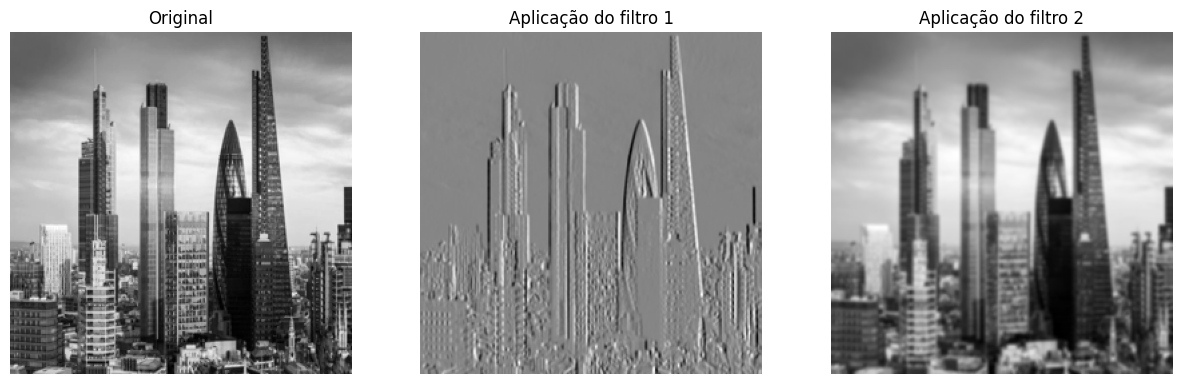

In [36]:
path_dataset = path + 'City_images/'
selec_img = random.randint(1, 60)

img_ori = Image.open(path_dataset+'imgs_originais/'+f'{selec_img}.tif')
img_f1 = Image.open(path_dataset+'imgs_filt1/'+f'{selec_img}.tif')
img_f2 = Image.open(path_dataset+'imgs_filt2/'+f'{selec_img}.tif')

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(np.array(img_ori), cmap='gray')
plt.axis('off')
plt.title('Original')
plt.subplot(132)
plt.imshow(np.array(img_f1), cmap='gray')
plt.axis('off')
plt.title('Aplicação do filtro 1')
plt.subplot(133)
plt.imshow(np.array(img_f2), cmap='gray')
plt.axis('off')
plt.title('Aplicação do filtro 2');

Para facilitar a visualização dos filtros aprendidos pela rede, vamos utilizar o código abaixo, que gera um **gif** a partir de um conjunto de arrays. Tente entender o código a partir do exemplo dado.

In [37]:
# Criando um conjunto de arrays para exemplificar o código
array_list = []
array_inicial = np.array([[0,0,0,0,0,0,0,0,0,0,0,0]]*6, dtype='uint8')
array_list.append(array_inicial)
for i in range(12):
    tmp = array_inicial.copy()
    tmp[2:4,:i+1] = 1
    array_list.append(tmp)

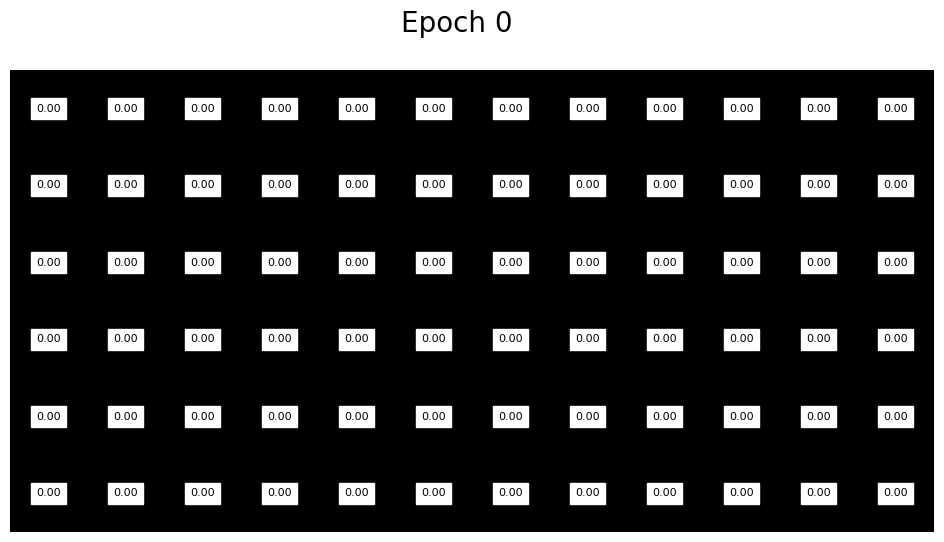

In [38]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Gif generation
images = np.array(array_list)
vmin = images.min()
vmax = images.max()
fig = plt.figure(figsize=(12,6))

# Function to update the image and add text annotations
def update(frame):
    plt.clf()  # Clear the previous plot
    fig.suptitle("Epoch {}".format(frame), fontsize=20) # Define the title
    plt.imshow(images[frame], vmin=vmin, vmax=vmax, cmap='gray') # Generate the image
    plt.axis('off')
    # Add text annotations
    for (i, j), value in np.ndenumerate(images[frame]):
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=8, backgroundcolor='white')

# Creating the animation
anim = FuncAnimation(fig, update, frames=len(images), interval=200)
# Displaying the animation in the notebook
html = anim.to_jshtml()
HTML(html)

### Exercício 4.1

Crie uma CNN composta por apenas uma camada convolucional com kernel de tamanho 3x3, que utilize as imagens originais como entrada e tenha como "gabarito" o primeiro conjunto de imagens filtradas (**imgs_filt1**). Você precisará definir uma função de loss, um otimizador para a rede e o número de épocas para treinamento. Então, treine a rede com as imagens especificadas, acompanhando os valores de loss a cada época. Você deve armazenar em uma lista os pesos do kernel da rede a cada época do treinamento.

Após o treinamento, visualize a progressão dos pesos do kernel utilizando o código de geração de **gif** dado anteriormente. Comente os métodos utilizados e resultados obtidos. A partir do **gif** obtido, você é capaz de dizer que filtro foi utilizado para gerar o conjunto de imagens da pasta **imgs_filt1**?

Shape da entrada: torch.Size([60, 1, 256, 256])
Shape do gabarito: torch.Size([60, 1, 256, 256])
Faixa X: 0.0 até 1.0
Faixa Y: 0.0 até 1.0


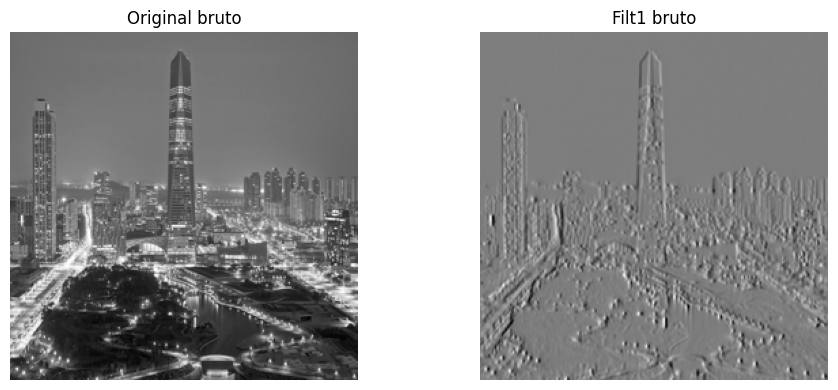

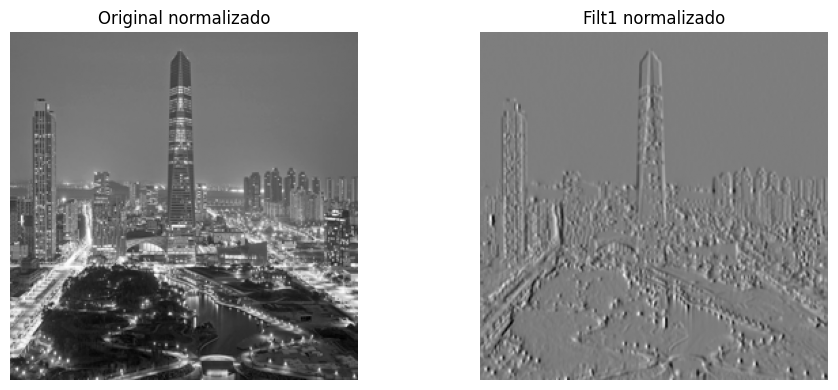

SimpleCNN(
  (conv): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
)
Shape dos pesos: torch.Size([1, 1, 3, 3])
Época 1/20 - Loss: 0.07709993
Época 2/20 - Loss: 0.06702857
Época 3/20 - Loss: 0.06124002
Época 4/20 - Loss: 0.05936100
Época 5/20 - Loss: 0.06029811
Época 6/20 - Loss: 0.06227266
Época 7/20 - Loss: 0.06367776
Época 8/20 - Loss: 0.06387036
Época 9/20 - Loss: 0.06303693
Época 10/20 - Loss: 0.06170217
Época 11/20 - Loss: 0.06039778
Época 12/20 - Loss: 0.05950690
Época 13/20 - Loss: 0.05919681
Época 14/20 - Loss: 0.05940912
Época 15/20 - Loss: 0.05991190
Época 16/20 - Loss: 0.06041058
Época 17/20 - Loss: 0.06067343
Época 18/20 - Loss: 0.06060873
Época 19/20 - Loss: 0.06026730
Época 20/20 - Loss: 0.05979134


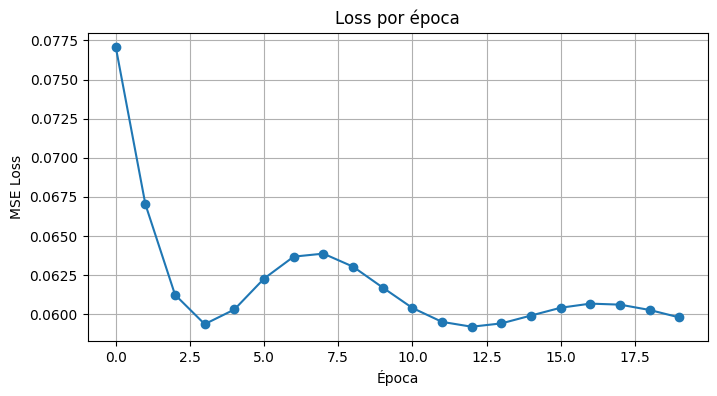

Kernel final aprendido:

[[ 0.22239031 -0.15496537  0.25793207]
 [ 0.08640882  0.23339097  0.14172731]
 [-0.30790678  0.04734534  0.30773067]]


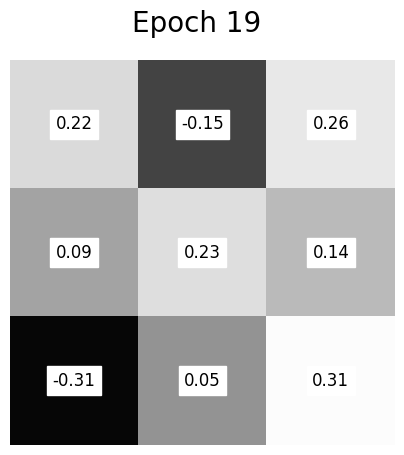

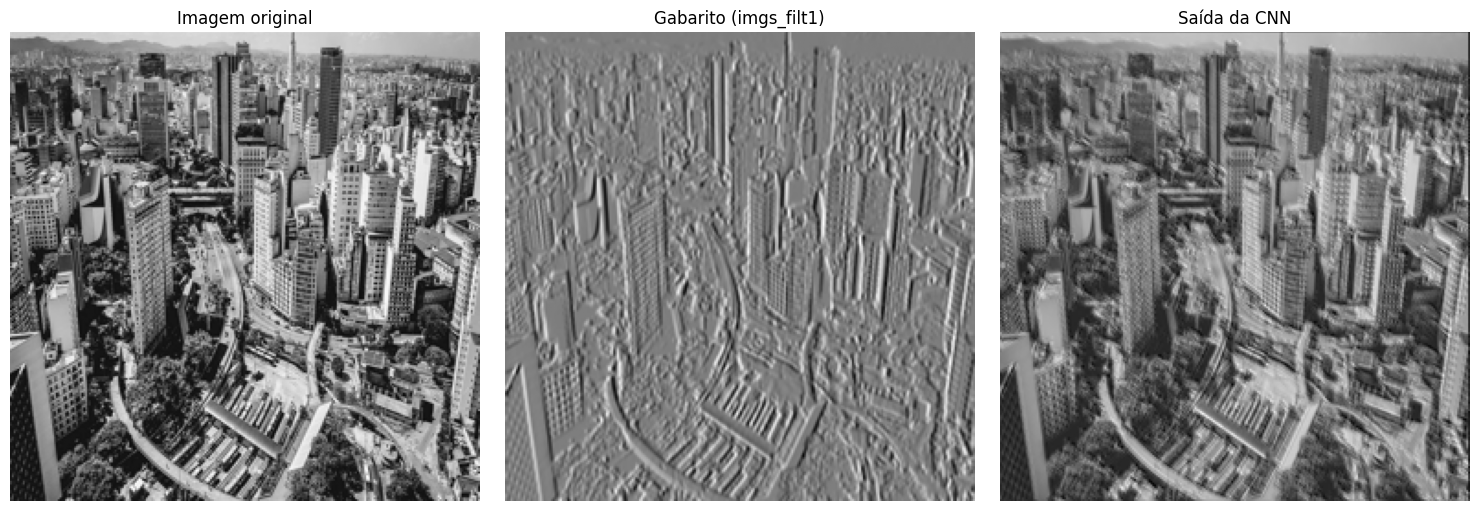

In [74]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

import torch
import torch.nn as nn
import torch.optim as optim


# 1. Caminhos do dataset
path_dataset = path + 'City_images/'
path_x = path_dataset + 'imgs_originais/'
path_y = path_dataset + 'imgs_filt1/'

# 2. Carregamento correto
X_raw_list = []
Y_raw_list = []
X_list = []
Y_list = []

for i in range(1, 61):
    img_x = np.array(Image.open(path_x + f'{i}.tif'), dtype=np.float32)
    img_y = np.array(Image.open(path_y + f'{i}.tif'), dtype=np.float32)

    if img_x.ndim == 3:
        img_x = img_x[..., 0]
    if img_y.ndim == 3:
        img_y = img_y[..., 0]

    # guardar bruto para visualização
    X_raw_list.append(img_x.copy())
    Y_raw_list.append(img_y.copy())

    # normalização por imagem para treino
    img_x_norm = img_x.copy()
    img_y_norm = img_y.copy()

    if img_x_norm.max() > img_x_norm.min():
        img_x_norm = (img_x_norm - img_x_norm.min()) / (img_x_norm.max() - img_x_norm.min())

    if img_y_norm.max() > img_y_norm.min():
        img_y_norm = (img_y_norm - img_y_norm.min()) / (img_y_norm.max() - img_y_norm.min())

    X_list.append(img_x_norm)
    Y_list.append(img_y_norm)

X_raw = np.array(X_raw_list)
Y_raw = np.array(Y_raw_list)

X = np.array(X_list)
Y = np.array(Y_list)

# adicionar dimensão de canal -> (N, C, H, W)
X = torch.tensor(X[:, np.newaxis, :, :], dtype=torch.float32)
Y = torch.tensor(Y[:, np.newaxis, :, :], dtype=torch.float32)

print("Shape da entrada:", X.shape)
print("Shape do gabarito:", Y.shape)
print("Faixa X:", X.min().item(), "até", X.max().item())
print("Faixa Y:", Y.min().item(), "até", Y.max().item())


# 3. Checagem visual
idx_check = 0

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(X_raw[idx_check], cmap='gray')
plt.title('Original bruto')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(Y_raw[idx_check], cmap='gray')
plt.title('Filt1 bruto')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(X[idx_check, 0].numpy(), cmap='gray')
plt.title('Original normalizado')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(Y[idx_check, 0].numpy(), cmap='gray')
plt.title('Filt1 normalizado')
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Definição da CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=1,
            kernel_size=3,
            padding=1,
            bias=False
        )

    def forward(self, x):
        return self.conv(x)

model = SimpleCNN()

print(model)
print("Shape dos pesos:", model.conv.weight.shape)   # esperado: [1, 1, 3, 3]


# 5. Loss, otimizador e treino
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 20

loss_history = []
kernel_history = []

# 6. Treinamento
for epoch in range(num_epochs):
    model.train()

    optimizer.zero_grad()

    output = model(X)
    loss = criterion(output, Y)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    # salvar exatamente o kernel 3x3
    kernel = model.conv.weight.detach().cpu().numpy()[0, 0].copy()
    kernel_history.append(kernel)

    print(f'Época {epoch+1}/{num_epochs} - Loss: {loss.item():.8f}')


# 7. Gráfico da loss
plt.figure(figsize=(8,4))
plt.plot(loss_history, marker='o')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()


# 8. Kernel final aprendido
kernel_final = model.conv.weight.detach().cpu().numpy()[0, 0]

print("Kernel final aprendido:\n")
print(kernel_final)


# 9. Gif da evolução do kernel
images = np.array(kernel_history)   # shape: (épocas, 3, 3)

vmin = images.min()
vmax = images.max()

fig = plt.figure(figsize=(5,5))

def update(frame):
    plt.clf()
    fig.suptitle(f"Epoch {frame}", fontsize=20)
    plt.imshow(images[frame], vmin=vmin, vmax=vmax, cmap='gray')
    plt.axis('off')

    for (i, j), value in np.ndenumerate(images[frame]):
        plt.text(
            j, i, f'{value:.2f}',
            ha='center',
            va='center',
            color='black',
            fontsize=12,
            backgroundcolor='white'
        )

anim = FuncAnimation(fig, update, frames=len(images), interval=500)
display(HTML(anim.to_jshtml()))


# 10. Comparação final
idx = random.randint(0, 59)

img_in_raw = X_raw[idx]
img_target_raw = Y_raw[idx]

with torch.no_grad():
    img_pred = model(X[idx:idx+1]).detach().cpu().numpy()[0, 0]

def norm_vis(img):
    img = img.astype(np.float32)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return img

img_in_vis = norm_vis(img_in_raw)
img_target_vis = norm_vis(img_target_raw)
img_pred_vis = norm_vis(img_pred)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_in_vis, cmap='gray')
plt.title('Imagem original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_target_vis, cmap='gray')
plt.title('Gabarito (imgs_filt1)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_pred_vis, cmap='gray')
plt.title('Saída da CNN')
plt.axis('off')

plt.tight_layout()
plt.show()

Foi treinada uma CNN com apenas uma camada convolucional de tamanho 3x3, usando as imagens originais como entrada e as imagens da pasta imgs_filt1 como gabarito. Para o treinamento, foi utilizada a função de perda MSELoss, que mede a diferença entre a saída da rede e a imagem desejada, e o otimizador Adam, responsável por ajustar os pesos do kernel ao longo das épocas. Durante o treinamento, os pesos do kernel foram armazenados em uma lista para permitir a visualização da sua evolução em forma de gif.

Observando o gif, percebe-se que os valores do kernel mudam mais nas primeiras épocas e depois passam a se estabilizar. Isso indica que a rede aprendeu um padrão e convergiu para uma solução relativamente estável. A curva de loss também confirma isso, pois há redução do erro ao longo do treinamento. O kernel aprendido apresenta valores positivos e negativos, o que é típico de filtros de realce de bordas, e não de filtros suavizantes como média ou gaussiano. Além disso, o padrão visual do gabarito imgs_filt1 lembra um efeito de relevo/realce direcional, com contornos claros e escuros ao redor das estruturas da imagem. Portanto, a partir do gif obtido, é possível concluir que o conjunto imgs_filt1 foi gerado por um filtro aguçante de realce de bordas, provavelmente semelhante a um filtro emboss ou a algum filtro direcional de detecção/realce de contornos.

### Exercício 4.2

Repita o processo realizado no exercício 5.1, mas dessa vez crie uma CNN composta por duas camadas convolucionais, a primeira com kernel de tamanho 1x5 e a segunda com kernel de tamanho 5x1. Você deve utilizar como "gabarito" o segundo conjunto de imagens filtradas (**imgs_filt2**). Armazene os pesos dos kernels da rede a cada época do treinamento em duas listas, uma para cada kernel.

Após o treinamento, visualize a progressão dos pesos de cada kernel utilizando o código de geração de **gif** dado anteriormente. Comente os métodos utilizados e resultados obtidos. A partir dos **gifs** obtidos, você é capaz de dizer que filtro foi utilizado para gerar o conjunto de imagens da pasta **imgs_filt2**?

Shape da entrada: torch.Size([60, 1, 256, 256])
Shape do gabarito: torch.Size([60, 1, 256, 256])
Faixa X: 0.0 até 1.0
Faixa Y: 0.0 até 1.0


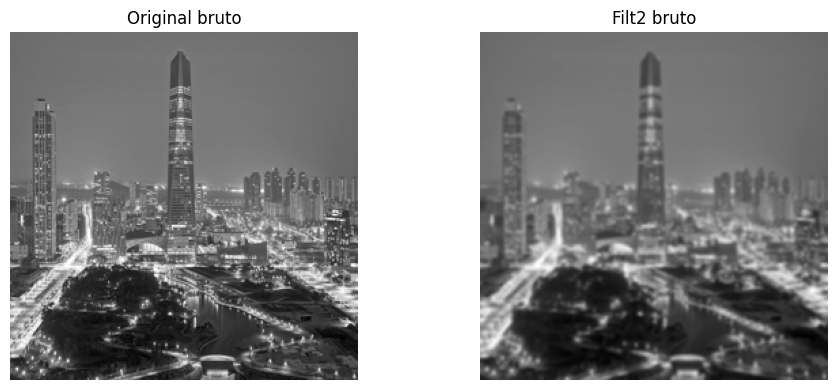

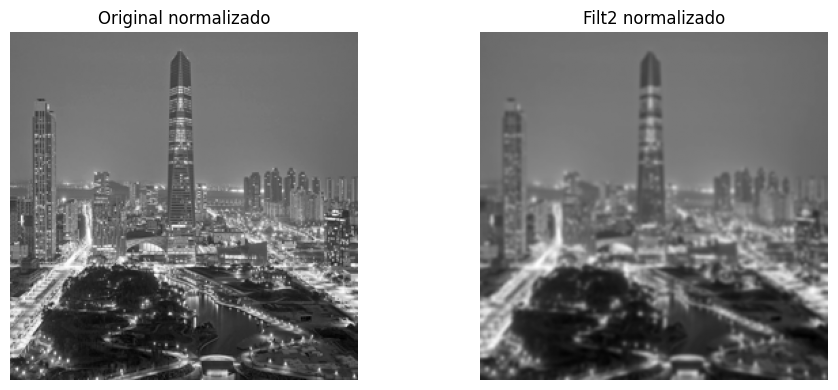

TwoLayerCNN(
  (conv1): Conv2d(1, 1, kernel_size=(1, 5), stride=(1, 1), padding=(0, 2), bias=False)
  (conv2): Conv2d(1, 1, kernel_size=(5, 1), stride=(1, 1), padding=(2, 0), bias=False)
)
Shape conv1: torch.Size([1, 1, 1, 5])
Shape conv2: torch.Size([1, 1, 5, 1])
Época 1/30 - Loss: 0.26280773
Época 2/30 - Loss: 0.24413273
Época 3/30 - Loss: 0.22422442
Época 4/30 - Loss: 0.20318031
Época 5/30 - Loss: 0.18123612
Época 6/30 - Loss: 0.15869859
Época 7/30 - Loss: 0.13594040
Época 8/30 - Loss: 0.11339972
Época 9/30 - Loss: 0.09157969
Época 10/30 - Loss: 0.07104532
Época 11/30 - Loss: 0.05241194
Época 12/30 - Loss: 0.03632271
Época 13/30 - Loss: 0.02340848
Época 14/30 - Loss: 0.01421544
Época 15/30 - Loss: 0.00909432
Época 16/30 - Loss: 0.00804531
Época 17/30 - Loss: 0.01054897
Época 18/30 - Loss: 0.01548374
Época 19/30 - Loss: 0.02127703
Época 20/30 - Loss: 0.02632471
Época 21/30 - Loss: 0.02946863
Época 22/30 - Loss: 0.03023834
Época 23/30 - Loss: 0.02879173
Época 24/30 - Loss: 0.02569512


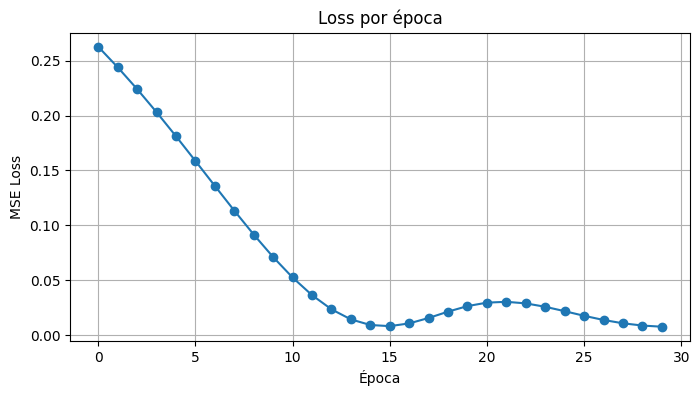

Kernel final da camada 1 (1x5):

[[ 0.31625235  0.38681856 -0.04183059 -0.1391315   0.26299542]]

Kernel final da camada 2 (5x1):

[[-0.09828827]
 [ 0.33412576]
 [ 0.18537945]
 [ 0.36255044]
 [ 0.502685  ]]


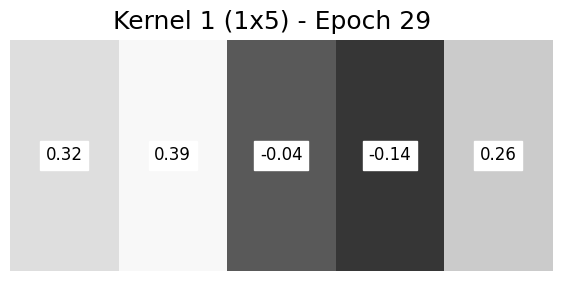

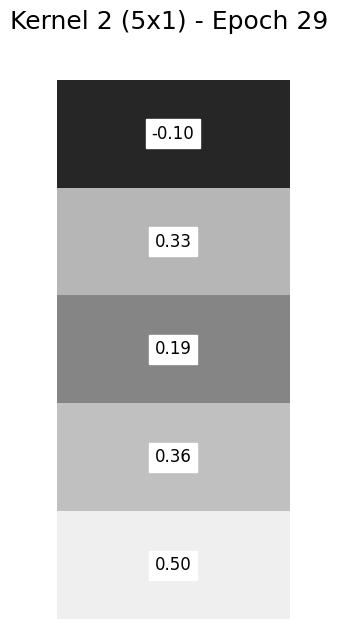

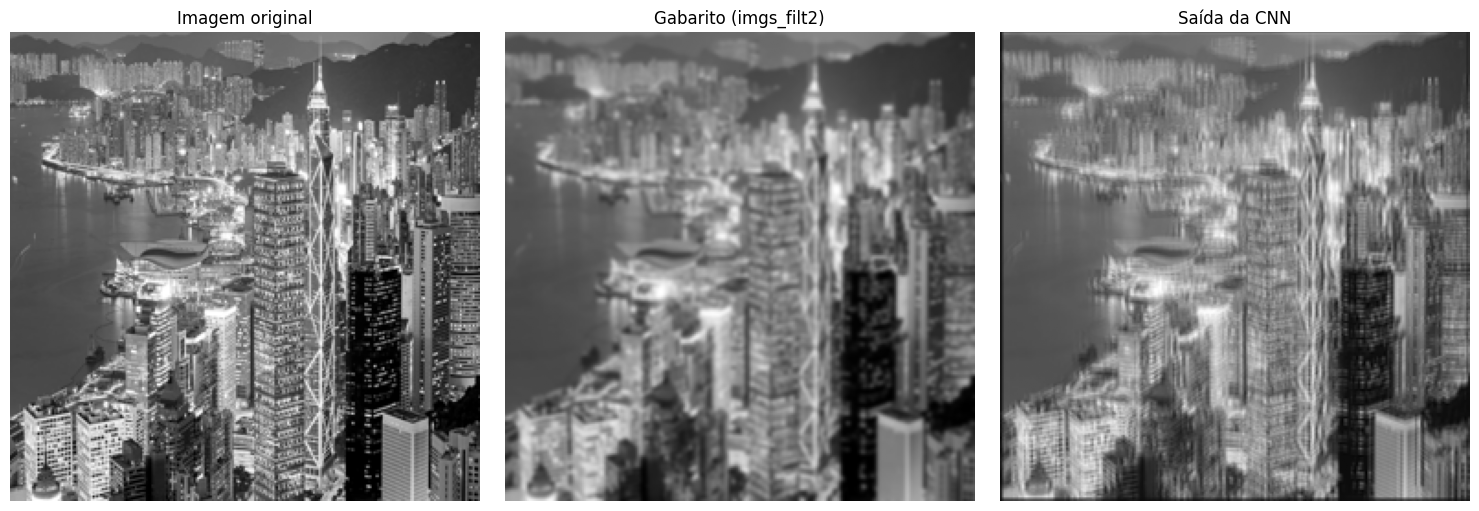

In [72]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

import torch
import torch.nn as nn
import torch.optim as optim


# 1. Caminhos do dataset
path_dataset = path + 'City_images/'
path_x = path_dataset + 'imgs_originais/'
path_y = path_dataset + 'imgs_filt2/'


# 2. Carregamento correto
X_raw_list = []
Y_raw_list = []
X_list = []
Y_list = []

for i in range(1, 61):
    img_x = np.array(Image.open(path_x + f'{i}.tif'), dtype=np.float32)
    img_y = np.array(Image.open(path_y + f'{i}.tif'), dtype=np.float32)

    if img_x.ndim == 3:
        img_x = img_x[..., 0]
    if img_y.ndim == 3:
        img_y = img_y[..., 0]

    # guardar bruto para visualização
    X_raw_list.append(img_x.copy())
    Y_raw_list.append(img_y.copy())

    # normalização por imagem para treino
    img_x_norm = img_x.copy()
    img_y_norm = img_y.copy()

    if img_x_norm.max() > img_x_norm.min():
        img_x_norm = (img_x_norm - img_x_norm.min()) / (img_x_norm.max() - img_x_norm.min())

    if img_y_norm.max() > img_y_norm.min():
        img_y_norm = (img_y_norm - img_y_norm.min()) / (img_y_norm.max() - img_y_norm.min())

    X_list.append(img_x_norm)
    Y_list.append(img_y_norm)

X_raw = np.array(X_raw_list)
Y_raw = np.array(Y_raw_list)

X = np.array(X_list)
Y = np.array(Y_list)

X = torch.tensor(X[:, np.newaxis, :, :], dtype=torch.float32)
Y = torch.tensor(Y[:, np.newaxis, :, :], dtype=torch.float32)

print("Shape da entrada:", X.shape)
print("Shape do gabarito:", Y.shape)
print("Faixa X:", X.min().item(), "até", X.max().item())
print("Faixa Y:", Y.min().item(), "até", Y.max().item())

# 3. Visualização de checagem
idx_check = 0

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(X_raw[idx_check], cmap='gray')
plt.title('Original bruto')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(Y_raw[idx_check], cmap='gray')
plt.title('Filt2 bruto')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(X[idx_check, 0].numpy(), cmap='gray')
plt.title('Original normalizado')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(Y[idx_check, 0].numpy(), cmap='gray')
plt.title('Filt2 normalizado')
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. CNN com 2 camadas separáveis
class TwoLayerCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=1,
            kernel_size=(1, 5),
            padding=(0, 2),
            bias=False
        )
        self.conv2 = nn.Conv2d(
            in_channels=1,
            out_channels=1,
            kernel_size=(5, 1),
            padding=(2, 0),
            bias=False
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return x

model = TwoLayerCNN()

print(model)
print("Shape conv1:", model.conv1.weight.shape)   # [1,1,1,5]
print("Shape conv2:", model.conv2.weight.shape)   # [1,1,5,1]

# 5. Loss e otimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 30

loss_history = []
kernel1_history = []
kernel2_history = []


# 6. Treinamento
for epoch in range(num_epochs):
    model.train()

    optimizer.zero_grad()

    output = model(X)
    loss = criterion(output, Y)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    kernel1 = model.conv1.weight.detach().cpu().numpy()[0, 0].copy()   # (1,5)
    kernel2 = model.conv2.weight.detach().cpu().numpy()[0, 0].copy()   # (5,1)

    kernel1_history.append(kernel1)
    kernel2_history.append(kernel2)

    print(f'Época {epoch+1}/{num_epochs} - Loss: {loss.item():.8f}')


# 7. Gráfico da loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker='o')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()


# 8. Kernels finais
kernel1_final = model.conv1.weight.detach().cpu().numpy()[0, 0]
kernel2_final = model.conv2.weight.detach().cpu().numpy()[0, 0]

print("Kernel final da camada 1 (1x5):\n")
print(kernel1_final)

print("\nKernel final da camada 2 (5x1):\n")
print(kernel2_final)


# 9. Gif kernel 1
images1 = np.array(kernel1_history)
vmin1 = images1.min()
vmax1 = images1.max()

fig1 = plt.figure(figsize=(7, 3))

def update1(frame):
    plt.clf()
    fig1.suptitle(f"Kernel 1 (1x5) - Epoch {frame}", fontsize=18)
    plt.imshow(images1[frame], vmin=vmin1, vmax=vmax1, cmap='gray', aspect='auto')
    plt.axis('off')

    for (i, j), value in np.ndenumerate(images1[frame]):
        plt.text(
            j, i, f'{value:.2f}',
            ha='center', va='center',
            color='black', fontsize=12,
            backgroundcolor='white'
        )

anim1 = FuncAnimation(fig1, update1, frames=len(images1), interval=400)
display(HTML(anim1.to_jshtml()))


# 10. Gif kernel 2
images2 = np.array(kernel2_history)
vmin2 = images2.min()
vmax2 = images2.max()

fig2 = plt.figure(figsize=(3, 7))

def update2(frame):
    plt.clf()
    fig2.suptitle(f"Kernel 2 (5x1) - Epoch {frame}", fontsize=18)
    plt.imshow(images2[frame], vmin=vmin2, vmax=vmax2, cmap='gray', aspect='auto')
    plt.axis('off')

    for (i, j), value in np.ndenumerate(images2[frame]):
        plt.text(
            j, i, f'{value:.2f}',
            ha='center', va='center',
            color='black', fontsize=12,
            backgroundcolor='white'
        )

anim2 = FuncAnimation(fig2, update2, frames=len(images2), interval=400)
display(HTML(anim2.to_jshtml()))


# 11. Comparação final
idx = random.randint(0, 59)

img_in_raw = X_raw[idx]
img_target_raw = Y_raw[idx]

img_in = X[idx, 0].detach().cpu().numpy()
img_target = Y[idx, 0].detach().cpu().numpy()

with torch.no_grad():
    img_pred = model(X[idx:idx+1]).detach().cpu().numpy()[0, 0]

def norm_vis(img):
    img = img.astype(np.float32)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return img

img_in_vis = norm_vis(img_in_raw)
img_target_vis = norm_vis(img_target_raw)
img_pred_vis = norm_vis(img_pred)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_in_vis, cmap='gray')
plt.title('Imagem original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_target_vis, cmap='gray')
plt.title('Gabarito (imgs_filt2)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_pred_vis, cmap='gray')
plt.title('Saída da CNN')
plt.axis('off')

plt.tight_layout()
plt.show()

A CNN com duas camadas convolucionais (1x5 e 5x1) conseguiu aprender parte da transformação entre as imagens originais e imgs_filt2, como mostrado pela redução da loss e pela estabilização gradual dos pesos nos gifs. Como a arquitetura impõe um filtro separável e o resultado visual corresponde a um borramento da imagem, conclui-se que imgs_filt2 foi gerado por um filtro suavizante separável, provavelmente um filtro gaussiano.